<a href="https://colab.research.google.com/github/shuangquan-li-con/ECON5200-37499-Applied-Data-Analytics-in-Economics/blob/main/The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
!pip install wbgapi scikit-learn pandas numpy matplotlib

In [68]:
import warnings
warnings.filterwarnings("ignore")

import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path
from sklearn.metrics import r2_score, mean_squared_error

In [69]:
indicator_dict = {
    "NY.GDP.PCAP.KD.ZG": "gdp_growth_pc",
    "SP.DYN.LE00.IN": "life_expectancy",
    "SP.DYN.IMRT.IN": "infant_mortality",
    "SP.DYN.TFRT.IN": "fertility",
    "SP.POP.GROW": "pop_growth",
    "SL.UEM.TOTL.ZS": "unemployment",
    "FP.CPI.TOTL.ZG": "inflation",
    "NE.GDI.TOTL.ZS": "investment_share",
    "NE.EXP.GNFS.ZS": "exports_share",
    "NE.IMP.GNFS.ZS": "imports_share",
    "BX.KLT.DINV.WD.GD.ZS": "fdi_share",
    "GC.DOD.TOTL.GD.ZS": "public_debt",
    "GC.XPN.TOTL.GD.ZS": "gov_expenditure",
    "GC.TAX.TOTL.GD.ZS": "tax_revenue",
    "NV.AGR.TOTL.ZS": "agriculture_share",
    "NV.IND.TOTL.ZS": "industry_share",
    "NV.SRV.TOTL.ZS": "services_share",
    "SE.ADT.LITR.ZS": "adult_literacy",
    "SE.SEC.ENRR": "secondary_enrollment",
    "SE.TER.ENRR": "tertiary_enrollment",
    "SH.XPD.CHEX.GD.ZS": "health_spending",
    "EG.USE.PCAP.KG.OE": "energy_use",
    "IT.NET.USER.ZS": "internet_users",
    "FS.AST.PRVT.GD.ZS": "private_credit",
    "FM.LBL.BMNY.GD.ZS": "broad_money",
    "PA.NUS.FCRF": "exchange_rate",
    "NE.TRD.GNFS.ZS": "trade_share",
    "SP.RUR.TOTL.ZS": "rural_population",
    "SP.URB.TOTL.IN.ZS": "urban_population",
    "SI.POV.GINI": "gini",
    "SL.TLF.CACT.ZS": "labor_force_participation",
    "NE.CON.GOVT.ZS": "gov_consumption"
}

In [70]:
rows = []
bad_codes = []

for code, name in indicator_dict.items():
    print("Trying:", code)
    try:
        for r in wb.data.fetch(
            code,
            economy="all",
            time=range(2013, 2020),
            skipAggs=True,
            db=2
        ):
            rows.append({
                "economy": r["economy"],
                "time": r["time"],
                "series": code,
                "value": r["value"]
            })
        print("Success:", code)
    except Exception as e:
        bad_codes.append(code)
        print("Failed:", code, "|", e)

print("\nBad codes:", bad_codes)
print("Downloaded rows:", len(rows))

Trying: NY.GDP.PCAP.KD.ZG
Success: NY.GDP.PCAP.KD.ZG
Trying: SP.DYN.LE00.IN
Success: SP.DYN.LE00.IN
Trying: SP.DYN.IMRT.IN
Success: SP.DYN.IMRT.IN
Trying: SP.DYN.TFRT.IN
Success: SP.DYN.TFRT.IN
Trying: SP.POP.GROW
Success: SP.POP.GROW
Trying: SL.UEM.TOTL.ZS
Success: SL.UEM.TOTL.ZS
Trying: FP.CPI.TOTL.ZG
Success: FP.CPI.TOTL.ZG
Trying: NE.GDI.TOTL.ZS
Success: NE.GDI.TOTL.ZS
Trying: NE.EXP.GNFS.ZS
Success: NE.EXP.GNFS.ZS
Trying: NE.IMP.GNFS.ZS
Success: NE.IMP.GNFS.ZS
Trying: BX.KLT.DINV.WD.GD.ZS
Success: BX.KLT.DINV.WD.GD.ZS
Trying: GC.DOD.TOTL.GD.ZS
Success: GC.DOD.TOTL.GD.ZS
Trying: GC.XPN.TOTL.GD.ZS
Success: GC.XPN.TOTL.GD.ZS
Trying: GC.TAX.TOTL.GD.ZS
Success: GC.TAX.TOTL.GD.ZS
Trying: NV.AGR.TOTL.ZS
Success: NV.AGR.TOTL.ZS
Trying: NV.IND.TOTL.ZS
Success: NV.IND.TOTL.ZS
Trying: NV.SRV.TOTL.ZS
Success: NV.SRV.TOTL.ZS
Trying: SE.ADT.LITR.ZS
Success: SE.ADT.LITR.ZS
Trying: SE.SEC.ENRR
Success: SE.SEC.ENRR
Trying: SE.TER.ENRR
Success: SE.TER.ENRR
Trying: SH.XPD.CHEX.GD.ZS
Success: SH.XPD.

In [71]:
raw_long = pd.DataFrame(rows)

name_map = pd.DataFrame({
    "series": list(indicator_dict.keys()),
    "varname": list(indicator_dict.values())
})

raw_long = raw_long.merge(name_map, on="series", how="left")

raw_wide = raw_long.pivot_table(
    index=["economy", "time"],
    columns="varname",
    values="value",
    aggfunc="mean"
).reset_index()

print("Raw wide shape:", raw_wide.shape)
raw_wide.head()

Raw wide shape: (1519, 34)


varname,economy,time,adult_literacy,agriculture_share,broad_money,energy_use,exchange_rate,exports_share,fdi_share,fertility,...,private_credit,public_debt,rural_population,secondary_enrollment,services_share,tax_revenue,tertiary_enrollment,trade_share,unemployment,urban_population
0,ABW,YR2013,NaN,0.017817,67.419642,NaN,1.79,73.576436,9.974457,1.944,...,59.163685,NaN,36.361709,NaN,80.180837,NaN,17.125870,155.731904,NaN,63.638291
1,ABW,YR2014,NaN,0.014813,69.586944,NaN,1.79,75.454623,7.465255,1.944,...,60.240539,NaN,36.560747,NaN,80.228644,NaN,17.751900,156.491053,NaN,63.439253
2,ABW,YR2015,NaN,0.012520,71.741795,NaN,1.79,70.321723,-0.907264,1.899,...,56.626882,NaN,36.771163,NaN,79.139068,NaN,16.731239,140.493001,NaN,63.228837
3,ABW,YR2016,NaN,0.018612,78.012085,NaN,1.79,68.966660,0.923397,1.848,...,57.221932,NaN,36.992212,NaN,78.731072,NaN,17.141621,136.887263,NaN,63.007788
4,ABW,YR2017,NaN,0.023919,76.595454,NaN,1.79,69.636936,5.253375,1.785,...,57.246534,NaN,37.223151,NaN,78.987908,NaN,NaN,138.716620,NaN,62.776849


In [72]:
country_means = raw_wide.drop(columns=["time"]).groupby("economy").mean(numeric_only=True)

country_means = country_means.dropna(subset=["gdp_growth_pc"]).copy()

row_missing = country_means.isna().mean(axis=1)
country_means = country_means.loc[row_missing <= 0.4].copy()

col_missing = country_means.isna().mean(axis=0)
country_means = country_means.loc[:, col_missing <= 0.4].copy()

country_means = country_means.fillna(country_means.median(numeric_only=True))

country_means["crisis"] = (country_means["gdp_growth_pc"] < 0).astype(int)

print("Final dataset shape:", country_means.shape)
print(country_means["crisis"].value_counts())
print("Base rate:", round(country_means["crisis"].mean(), 4))

Final dataset shape: (192, 31)
crisis
0    157
1     35
Name: count, dtype: int64
Base rate: 0.1823


In [73]:
feature_cols = [c for c in country_means.columns if c not in ["gdp_growth_pc", "crisis"]]

X = country_means[feature_cols].copy()
y = country_means["gdp_growth_pc"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Number of predictors:", len(feature_cols))

Train shape: (134, 29)
Test shape: (58, 29)
Number of predictors: 29


In [74]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

ols_train_pred = ols.predict(X_train_scaled)
ols_test_pred = ols.predict(X_test_scaled)

ols_train_r2 = r2_score(y_train, ols_train_pred)
ols_test_r2 = r2_score(y_test, ols_test_pred)
ols_gap = ols_train_r2 - ols_test_r2

p = X_train_scaled.shape[1]
n = X_train_scaled.shape[0]
pn_ratio = p / n

print("OLS Training R^2:", round(ols_train_r2, 4))
print("OLS Test R^2:", round(ols_test_r2, 4))
print("Train-Test R^2 gap:", round(ols_gap, 4))
print("p/n ratio:", round(pn_ratio, 4))

OLS Training R^2: 0.5657
OLS Test R^2: 0.192
Train-Test R^2 gap: 0.3736
p/n ratio: 0.2164


In [75]:
print("Step 1.1 written response:")
print(
    f"The model uses {p} predictors and {n} observations, so the p/n ratio is {pn_ratio:.3f}. "
    f"When the number of predictors is relatively large compared to the sample size, OLS has too many degrees of freedom and can fit noise in the training data. "
    f"This leads to low bias in-sample but high variance out-of-sample, which explains the gap between the training R^2 and test R^2."
)


Step 1.1 written response:
The model uses 29 predictors and 134 observations, so the p/n ratio is 0.216. When the number of predictors is relatively large compared to the sample size, OLS has too many degrees of freedom and can fit noise in the training data. This leads to low bias in-sample but high variance out-of-sample, which explains the gap between the training R^2 and test R^2.


In [76]:
alphas = np.logspace(-3, 3, 200)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_scaled, y_train)

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)
ridge_rmse = mean_squared_error(y_test, ridge_test_pred) ** 0.5
ridge_nonzero = int(np.sum(np.abs(ridge.coef_) > 1e-8))

lasso = LassoCV(alphas=alphas, cv=5, max_iter=20000, random_state=42)
lasso.fit(X_train_scaled, y_train)

lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

lasso_train_r2 = r2_score(y_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)
lasso_rmse = mean_squared_error(y_test, lasso_test_pred) ** 0.5
lasso_nonzero = int(np.sum(np.abs(lasso.coef_) > 1e-8))

ols_rmse = mean_squared_error(y_test, ols_test_pred) ** 0.5

In [77]:
comparison_table = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "lambda_star": [np.nan, ridge.alpha_, lasso.alpha_],
    "Non_zero_predictors": [p, ridge_nonzero, lasso_nonzero],
    "Training_R2": [ols_train_r2, ridge_train_r2, lasso_train_r2],
    "Test_R2": [ols_test_r2, ridge_test_r2, lasso_test_r2],
    "Test_RMSE": [ols_rmse, ridge_rmse, lasso_rmse]
})

comparison_table

,Model,lambda_star,Non_zero_predictors,Training_R2,Test_R2,Test_RMSE
0,OLS,NaN,29,0.565657,0.192017,2.305069
1,Ridge,164.467618,29,0.377202,0.233703,2.244818
2,Lasso,0.296730,10,0.388430,0.212422,2.275775


In [78]:
print("Step 1.2 written response:")
print(
    "Based on the results, I would recommend the Ridge model for operational forecasting because it achieves the highest test R^2. "
    "Compared to OLS, Ridge reduces variance by shrinking the coefficients, which improves out-of-sample performance. "
    "Lasso also reduces variance and performs variable selection, but in this case its test performance is slightly worse than Ridge. "
    "This reflects the bias-variance tradeoff, where both methods add some bias but gain stability in prediction."
)

Step 1.2 written response:
Based on the results, I would recommend the Ridge model for operational forecasting because it achieves the highest test R^2. Compared to OLS, Ridge reduces variance by shrinking the coefficients, which improves out-of-sample performance. Lasso also reduces variance and performs variable selection, but in this case its test performance is slightly worse than Ridge. This reflects the bias-variance tradeoff, where both methods add some bias but gain stability in prediction.


In [79]:
lasso_path_alphas, lasso_path_coefs, _ = lasso_path(X_train_scaled, y_train, alphas=alphas)

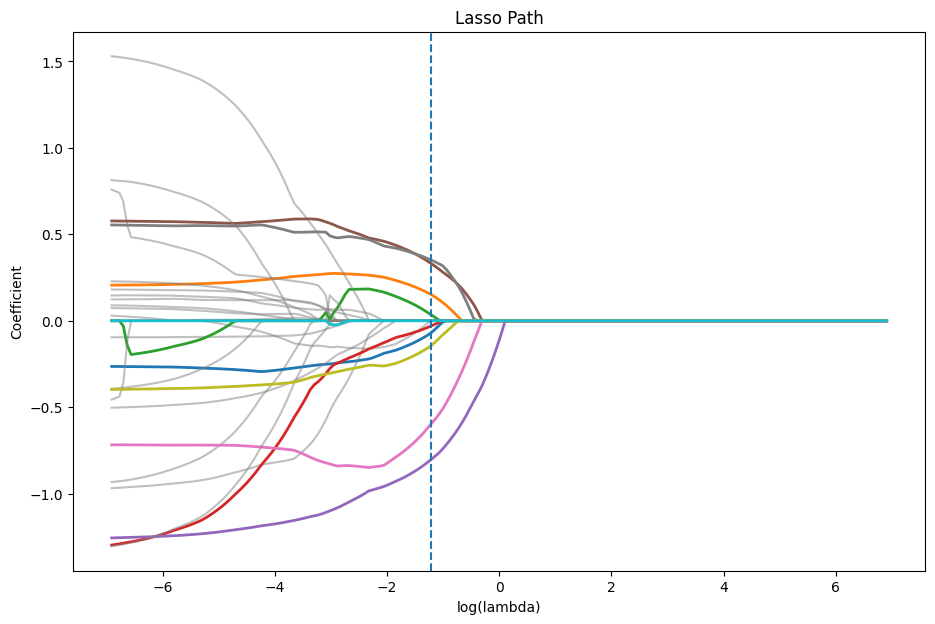

In [80]:
selected_mask = np.abs(lasso.coef_) > 1e-8

plt.figure(figsize=(11, 7))

for i, var in enumerate(feature_cols):
    if selected_mask[i]:
        plt.plot(np.log(lasso_path_alphas), lasso_path_coefs[i], linewidth=2)
    else:
        plt.plot(np.log(lasso_path_alphas), lasso_path_coefs[i], color="gray", alpha=0.5)

plt.axvline(np.log(lasso.alpha_), linestyle="--")
plt.xlabel("log(lambda)")
plt.ylabel("Coefficient")
plt.title("Lasso Path")
plt.show()

In [81]:
entry_points = {}

for i, var in enumerate(feature_cols):
    nonzero_idx = np.where(np.abs(lasso_path_coefs[i]) > 1e-8)[0]
    if len(nonzero_idx) > 0:
        entry_points[var] = nonzero_idx[0]

if len(entry_points) > 0:
    first_enter_feature = min(entry_points, key=entry_points.get)
else:
    first_enter_feature = "None"

print("First predictor to enter the model:", first_enter_feature)

First predictor to enter the model: inflation


In [82]:
print("Step 1.3 written response:")
print(
    f"The first predictor to enter the Lasso path is {first_enter_feature}, which suggests that it is one of the strongest unconditional predictors of cross-country growth. "
    "If Lasso sets life_expectancy to zero, it does not mean that health is irrelevant to growth. "
    "Instead, it may indicate conditional predictive redundancy, meaning that life expectancy is highly correlated with other development indicators. "
    "In this case, Lasso keeps one representative variable and drops others with similar information."
)

Step 1.3 written response:
The first predictor to enter the Lasso path is inflation, which suggests that it is one of the strongest unconditional predictors of cross-country growth. If Lasso sets life_expectancy to zero, it does not mean that health is irrelevant to growth. Instead, it may indicate conditional predictive redundancy, meaning that life expectancy is highly correlated with other development indicators. In this case, Lasso keeps one representative variable and drops others with similar information.


In [83]:
from sklearn.metrics import accuracy_score

In [84]:
y_class = country_means["crisis"].copy()

X_class = country_means[feature_cols].copy()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class,
    test_size=0.30,
    random_state=42,
    stratify=y_class
)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

X_train_c_scaled_df = pd.DataFrame(X_train_c_scaled, columns=feature_cols, index=X_train_c.index)
X_test_c_scaled_df = pd.DataFrame(X_test_c_scaled, columns=feature_cols, index=X_test_c.index)

print("Classification train shape:", X_train_c.shape)
print("Classification test shape:", X_test_c.shape)
print("Crisis rate in test set:", round(y_test_c.mean(), 4))

Classification train shape: (134, 29)
Classification test shape: (58, 29)
Crisis rate in test set: 0.1897


In [85]:
lasso_selected_features = list(np.array(feature_cols)[selected_mask])

if len(lasso_selected_features) == 0:
    coef_size = pd.Series(np.abs(lasso.coef_), index=feature_cols)
    lasso_selected_features = coef_size.sort_values(ascending=False).head(5).index.tolist()

print("Lasso-selected features:")
print(lasso_selected_features)
print("Number of selected features:", len(lasso_selected_features))

Lasso-selected features:
[np.str_('energy_use'), np.str_('exchange_rate'), np.str_('imports_share'), np.str_('industry_share'), np.str_('inflation'), np.str_('investment_share'), np.str_('pop_growth'), np.str_('rural_population'), np.str_('unemployment'), np.str_('urban_population')]
Number of selected features: 10


In [86]:
X_train_lpm = X_train_c_scaled_df[lasso_selected_features]
X_test_lpm = X_test_c_scaled_df[lasso_selected_features]

lpm = LinearRegression()
lpm.fit(X_train_lpm, y_train_c)

lpm_pred = lpm.predict(X_test_lpm)

below_zero = int(np.sum(lpm_pred < 0))
above_one = int(np.sum(lpm_pred > 1))
out_of_bounds = below_zero + above_one

print("Predictions below 0:", below_zero)
print("Predictions above 1:", above_one)
print("Total out-of-bounds predictions:", out_of_bounds)

Predictions below 0: 10
Predictions above 1: 1
Total out-of-bounds predictions: 11


In [87]:
print("Step 2.1 written response:")
print(
    f"The linear probability model produces {out_of_bounds} predicted values outside the [0, 1] range. "
    "This is a serious issue because probabilities must lie between 0 and 1. "
    "A negative probability or a value above 100% cannot be interpreted as a meaningful risk measure. "
    "For the IMF, such outputs would make the model unreliable for crisis prediction."
)

Step 2.1 written response:
The linear probability model produces 11 predicted values outside the [0, 1] range. This is a serious issue because probabilities must lie between 0 and 1. A negative probability or a value above 100% cannot be interpreted as a meaningful risk measure. For the IMF, such outputs would make the model unreliable for crisis prediction.


In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:
logit = LogisticRegression(max_iter=5000)
logit.fit(X_train_lpm, y_train_c)

logit_probs = logit.predict_proba(X_test_lpm)[:, 1]

beta_table = pd.DataFrame({
    "Predictor": lasso_selected_features,
    "Beta": logit.coef_[0]
})

beta_table["Odds_Ratio"] = np.exp(beta_table["Beta"])
beta_table["Abs_Log_OR"] = np.abs(beta_table["Beta"])

print("Intercept (beta_0):", round(logit.intercept_[0], 4))
beta_table = beta_table.sort_values("Abs_Log_OR", ascending=False).reset_index(drop=True)
beta_table

Intercept (beta_0): -1.8763


,Predictor,Beta,Odds_Ratio,Abs_Log_OR
0,inflation,1.453763,4.279185,1.453763
1,pop_growth,0.852077,2.344511,0.852077
2,energy_use,0.376864,1.457705,0.376864
3,unemployment,0.323968,1.382602,0.323968
4,imports_share,-0.273233,0.760915,0.273233
5,investment_share,-0.221141,0.801603,0.221141
6,urban_population,0.186680,1.205241,0.186680
7,rural_population,-0.186680,0.829710,0.186680
8,industry_share,0.098267,1.103257,0.098267
9,exchange_rate,-0.046007,0.955035,0.046007


In [90]:
print("Predicted probability min:", round(logit_probs.min(), 4))
print("Predicted probability max:", round(logit_probs.max(), 4))

Predicted probability min: 0.0056
Predicted probability max: 1.0


In [91]:
top_predictor = beta_table.iloc[0]["Predictor"]
top_or = beta_table.iloc[0]["Odds_Ratio"]

print("Largest odds ratio predictor:", top_predictor)
print("Odds ratio:", round(top_or, 4))

Largest odds ratio predictor: inflation
Odds ratio: 4.2792


In [92]:
print("Step 2.2 written response:")
print(
    f"A one standard-deviation increase in {top_predictor} multiplies the odds of crisis by {top_or:.2f}, holding all else constant. "
    "This suggests that countries with higher values of this variable are significantly more likely to experience a growth crisis."
)

Step 2.2 written response:
A one standard-deviation increase in inflation multiplies the odds of crisis by 4.28, holding all else constant. This suggests that countries with higher values of this variable are significantly more likely to experience a growth crisis.


In [93]:
X_train_one = X_train_c_scaled_df[[top_predictor]]
X_test_one = X_test_c_scaled_df[[top_predictor]]

lpm_one = LinearRegression()
lpm_one.fit(X_train_one, y_train_c)

logit_one = LogisticRegression(max_iter=5000)
logit_one.fit(X_train_one, y_train_c)

x_grid = np.linspace(X_test_one[top_predictor].min(), X_test_one[top_predictor].max(), 300)
x_grid_df = pd.DataFrame({top_predictor: x_grid})

lpm_curve = lpm_one.predict(x_grid_df)
logit_curve = logit_one.predict_proba(x_grid_df)[:, 1]

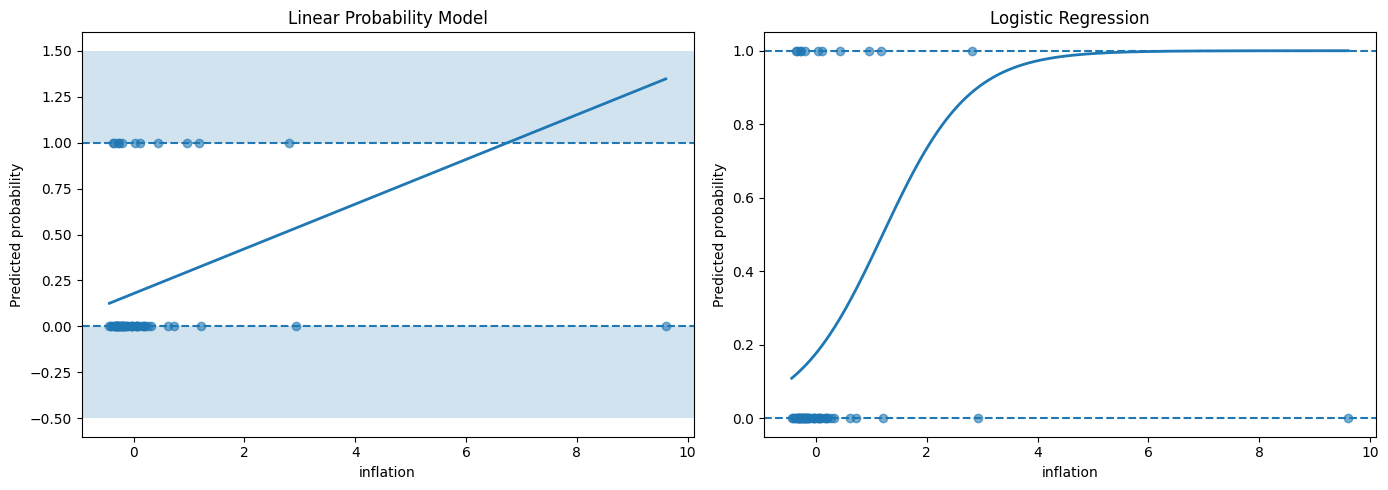

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_test_one[top_predictor], y_test_c, alpha=0.6)
axes[0].plot(x_grid, lpm_curve, linewidth=2)
axes[0].axhspan(-0.5, 0, alpha=0.2)
axes[0].axhspan(1, 1.5, alpha=0.2)
axes[0].axhline(0, linestyle="--")
axes[0].axhline(1, linestyle="--")
axes[0].set_title("Linear Probability Model")
axes[0].set_xlabel(top_predictor)
axes[0].set_ylabel("Predicted probability")

axes[1].scatter(X_test_one[top_predictor], y_test_c, alpha=0.6)
axes[1].plot(x_grid, logit_curve, linewidth=2)
axes[1].axhline(0, linestyle="--")
axes[1].axhline(1, linestyle="--")
axes[1].set_title("Logistic Regression")
axes[1].set_xlabel(top_predictor)
axes[1].set_ylabel("Predicted probability")

plt.tight_layout()
plt.show()

In [95]:
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score, accuracy_score
)

In [96]:
base_rate_test = y_test_c.mean()

naive_pred = np.zeros(len(y_test_c), dtype=int)
naive_accuracy = accuracy_score(y_test_c, naive_pred)
naive_recall = recall_score(y_test_c, naive_pred, zero_division=0)

logit_pred_05 = (logit_probs >= 0.5).astype(int)
logit_accuracy = accuracy_score(y_test_c, logit_pred_05)
logit_recall = recall_score(y_test_c, logit_pred_05, zero_division=0)

print("Test crisis base rate:", round(base_rate_test, 4))
print("Naive baseline accuracy:", round(naive_accuracy, 4))
print("Naive baseline recall:", round(naive_recall, 4))
print("Logistic accuracy at threshold 0.5:", round(logit_accuracy, 4))
print("Logistic recall at threshold 0.5:", round(logit_recall, 4))

Test crisis base rate: 0.1897
Naive baseline accuracy: 0.8103
Naive baseline recall: 0.0
Logistic accuracy at threshold 0.5: 0.7931
Logistic recall at threshold 0.5: 0.2727


In [97]:
print("Step 3.1 written response:")
print(
    f"The crisis base rate in the test set is {base_rate_test:.3f}. "
    f"The naive model achieves an accuracy of {naive_accuracy:.3f} but has zero recall, meaning it fails to detect any crisis cases. "
    f"In contrast, the logistic model has a slightly lower accuracy of {logit_accuracy:.3f} but a positive recall of {logit_recall:.3f}. "
    "This illustrates the accuracy paradox: a model can appear accurate simply by predicting the majority class, while failing at the task that actually matters, which is detecting crises."
)

Step 3.1 written response:
The crisis base rate in the test set is 0.190. The naive model achieves an accuracy of 0.810 but has zero recall, meaning it fails to detect any crisis cases. In contrast, the logistic model has a slightly lower accuracy of 0.793 but a positive recall of 0.273. This illustrates the accuracy paradox: a model can appear accurate simply by predicting the majority class, while failing at the task that actually matters, which is detecting crises.


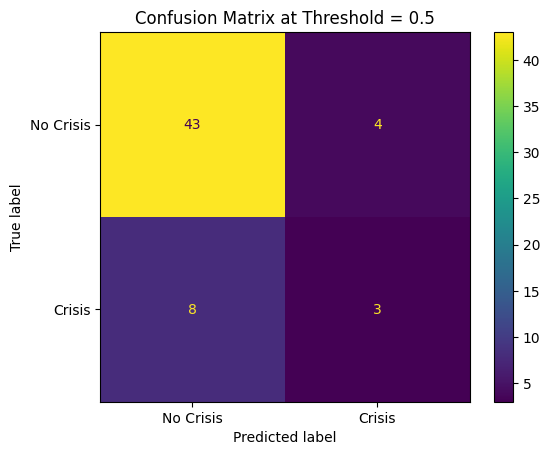

              precision    recall  f1-score   support

   No Crisis       0.84      0.91      0.88        47
      Crisis       0.43      0.27      0.33        11

    accuracy                           0.79        58
   macro avg       0.64      0.59      0.61        58
weighted avg       0.76      0.79      0.77        58



In [98]:
cm = confusion_matrix(y_test_c, logit_pred_05)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Crisis", "Crisis"])
disp.plot()
plt.title("Confusion Matrix at Threshold = 0.5")
plt.show()

print(classification_report(y_test_c, logit_pred_05, target_names=["No Crisis", "Crisis"], zero_division=0))

In [99]:
tn, fp, fn, tp = cm.ravel()

print("True Positives:", tp)
print("False Negatives:", fn)
print("False Positives:", fp)
print("True Negatives:", tn)

True Positives: 3
False Negatives: 8
False Positives: 4
True Negatives: 43


In [100]:
print("Step 3.2 written response:")
print(
    "In the IMF context, false negatives are far more costly than false positives. "
    "Missing a true crisis can lead to severe economic consequences and delayed intervention, while a false alarm mainly results in wasted resources. "
    "Because of this asymmetry, recall is more important than precision, as the IMF prioritizes detecting as many crisis countries as possible."
)

Step 3.2 written response:
In the IMF context, false negatives are far more costly than false positives. Missing a true crisis can lead to severe economic consequences and delayed intervention, while a false alarm mainly results in wasted resources. Because of this asymmetry, recall is more important than precision, as the IMF prioritizes detecting as many crisis countries as possible.


In [101]:
fpr, tpr, roc_thresholds = roc_curve(y_test_c, logit_probs)
roc_auc = roc_auc_score(y_test_c, logit_probs)

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test_c, logit_probs)
pr_auc = auc(recall_curve, precision_curve)

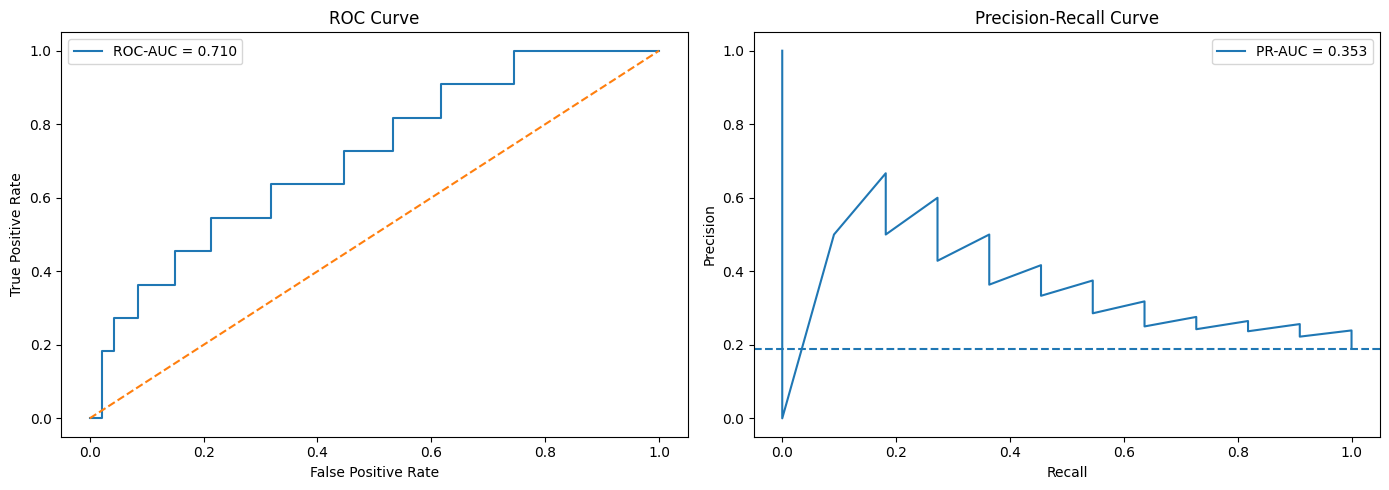

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.3f}")
axes[1].axhline(base_rate_test, linestyle="--")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

In [103]:
print("Step 3.3 written response:")
print(
    "The ROC-AUC is typically higher than the PR-AUC because ROC-AUC includes true negatives, which are abundant in an imbalanced dataset. "
    "In contrast, the precision-recall curve ignores true negatives and focuses only on the minority class. "
    "Since crisis cases are relatively rare, the precision-recall curve is more informative for evaluating the model’s ability to detect crises."
)

Step 3.3 written response:
The ROC-AUC is typically higher than the PR-AUC because ROC-AUC includes true negatives, which are abundant in an imbalanced dataset. In contrast, the precision-recall curve ignores true negatives and focuses only on the minority class. Since crisis cases are relatively rare, the precision-recall curve is more informative for evaluating the model’s ability to detect crises.


In [104]:
thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for tau in thresholds:
    pred_tau = (logit_probs >= tau).astype(int)
    flagged = int(pred_tau.sum())
    precision_tau = precision_score(y_test_c, pred_tau, zero_division=0)
    recall_tau = recall_score(y_test_c, pred_tau, zero_division=0)
    f1_tau = f1_score(y_test_c, pred_tau, zero_division=0)

    results.append({
        "threshold": tau,
        "flagged": flagged,
        "precision": precision_tau,
        "recall": recall_tau,
        "f1": f1_tau
    })

threshold_df = pd.DataFrame(results)
threshold_df.head()

,threshold,flagged,precision,recall,f1
0,0.01,57,0.192982,1.0,0.323529
1,0.02,54,0.203704,1.0,0.338462
2,0.03,47,0.234043,1.0,0.379310
3,0.04,47,0.234043,1.0,0.379310
4,0.05,46,0.239130,1.0,0.385965


In [105]:
thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for tau in thresholds:
    pred_tau = (logit_probs >= tau).astype(int)
    flagged = int(pred_tau.sum())
    precision_tau = precision_score(y_test_c, pred_tau, zero_division=0)
    recall_tau = recall_score(y_test_c, pred_tau, zero_division=0)
    f1_tau = f1_score(y_test_c, pred_tau, zero_division=0)

    results.append({
        "threshold": tau,
        "flagged": flagged,
        "precision": precision_tau,
        "recall": recall_tau,
        "f1": f1_tau
    })

threshold_df = pd.DataFrame(results)
threshold_df.head()

,threshold,flagged,precision,recall,f1
0,0.01,57,0.192982,1.0,0.323529
1,0.02,54,0.203704,1.0,0.338462
2,0.03,47,0.234043,1.0,0.379310
3,0.04,47,0.234043,1.0,0.379310
4,0.05,46,0.239130,1.0,0.385965


In [106]:
capacity_df = threshold_df[threshold_df["flagged"] <= 5].copy()

if len(capacity_df) > 0:
    capacity_row = capacity_df.sort_values("threshold").iloc[0]
else:
    capacity_row = threshold_df.sort_values("flagged").iloc[0]

f1_row = threshold_df.sort_values("f1", ascending=False).iloc[0]

capacity_tau = capacity_row["threshold"]
capacity_flagged = int(capacity_row["flagged"])
capacity_precision = capacity_row["precision"]
capacity_recall = capacity_row["recall"]

f1_tau = f1_row["threshold"]
f1_best = f1_row["f1"]

print("Capacity-constrained threshold:", round(capacity_tau, 2))
print("Countries flagged:", capacity_flagged)
print("Precision at capacity threshold:", round(capacity_precision, 4))
print("Recall at capacity threshold:", round(capacity_recall, 4))

print("\nF1-optimal threshold:", round(f1_tau, 2))
print("Best F1:", round(f1_best, 4))

Capacity-constrained threshold: 0.53
Countries flagged: 5
Precision at capacity threshold: 0.6
Recall at capacity threshold: 0.2727

F1-optimal threshold: 0.21
Best F1: 0.4444


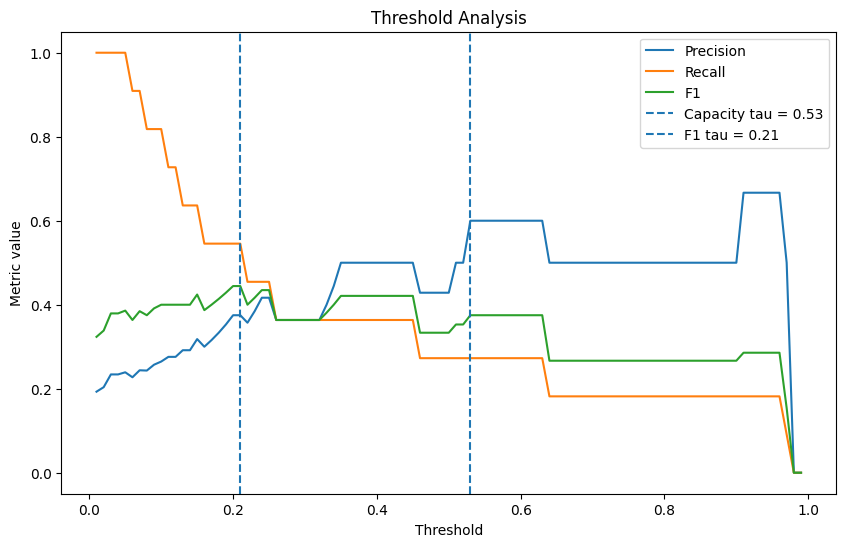

In [107]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")

plt.axvline(capacity_tau, linestyle="--", label=f"Capacity tau = {capacity_tau:.2f}")
plt.axvline(f1_tau, linestyle="--", label=f"F1 tau = {f1_tau:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Threshold Analysis")
plt.legend()
plt.show()

In [108]:
crisis_total = int(y_test_c.sum())

pred_capacity = (logit_probs >= capacity_tau).astype(int)
cm_capacity = confusion_matrix(y_test_c, pred_capacity)
tn_c, fp_c, fn_c, tp_c = cm_capacity.ravel()

print("Step 3.4 written response:")
print(
    f"I recommend using the capacity-constrained threshold of {capacity_tau:.2f}, since the IMF can only deploy up to 5 missions per quarter. "
    f"At this threshold, the model flags {capacity_flagged} countries and achieves a recall of {capacity_recall:.3f}. "
    f"Out of {int(y_test_c.sum())} crisis countries, the model correctly identifies {tp_c} and misses {fn_c}. "
    f"Although the F1-optimal threshold of {f1_tau:.2f} achieves a higher F1 score, it would exceed the operational capacity. "
    "Therefore, the capacity-constrained threshold is more realistic, even though it means some crises will be missed."
)

Step 3.4 written response:
I recommend using the capacity-constrained threshold of 0.53, since the IMF can only deploy up to 5 missions per quarter. At this threshold, the model flags 5 countries and achieves a recall of 0.273. Out of 11 crisis countries, the model correctly identifies 3 and misses 8. Although the F1-optimal threshold of 0.21 achieves a higher F1 score, it would exceed the operational capacity. Therefore, the capacity-constrained threshold is more realistic, even though it means some crises will be missed.


P — Prep:
I am working with a country-level training dataset called X_train_scaled_df and a continuous target called y_train. The predictors are standardized World Development Indicators, and I already used LassoCV for GDP per capita growth forecasting.

R — Request:
Write Python code that:
1. Draws 200 bootstrap resamples with replacement from the training data.
2. Fits LassoCV on each bootstrap sample using cv=5, random_state=42, and max_iter=20000.
3. Records whether each predictor receives a non-zero coefficient.
4. Computes the selection frequency for every predictor.
5. Produces a horizontal bar chart ranking predictors by selection frequency.
6. Adds a vertical reference line at 50%.

I — Iterate:
Keep the code simple and use only pandas, numpy, matplotlib, and scikit-learn.

M — Mechanism Check:
Use the existing variables X_train_scaled_df and y_train directly.
Return a DataFrame called selection_freq_df sorted from highest to lowest selection frequency.

E — Evaluate:
The final output should include the selection_freq_df table and the horizontal bar chart.

In [ ]:
np.random.seed(42)

n_boot = 200
selection_records = []

for b in range(n_boot):
    boot_idx = np.random.choice(X_train_c_scaled_df.index, size=len(X_train_c_scaled_df), replace=True)

    X_boot = X_train_c_scaled_df.loc[boot_idx]
    y_boot = y_train_c.loc[boot_idx]

    boot_lasso = LassoCV(alphas=alphas, cv=5, max_iter=20000, random_state=42)
    boot_lasso.fit(X_boot, y_boot)

    selected_now = (np.abs(boot_lasso.coef_) > 1e-8).astype(int)
    selection_records.append(selected_now)

selection_array = np.array(selection_records)

selection_freq_df = pd.DataFrame({
    "Predictor": feature_cols,
    "Selection_Frequency": selection_array.mean(axis=0)
})

selection_freq_df = selection_freq_df.sort_values("Selection_Frequency", ascending=False).reset_index(drop=True)

selection_freq_df.head(15)

In [ ]:
plt.figure(figsize=(10, 8))
plt.barh(selection_freq_df["Predictor"], selection_freq_df["Selection_Frequency"])
plt.axvline(0.5, linestyle="--")
plt.gca().invert_yaxis()
plt.xlabel("Selection Frequency")
plt.ylabel("Predictor")
plt.title("Bootstrap Lasso Selection Frequency")
plt.show()

In [ ]:
stable_predictors = selection_freq_df[selection_freq_df["Selection_Frequency"] > 0.8]["Predictor"].tolist()
fragile_predictors = selection_freq_df[selection_freq_df["Selection_Frequency"] < 0.3]["Predictor"].tolist()

print("Stable predictors (>80%):", stable_predictors)
print("Fragile predictors (<30%):", fragile_predictors)

In [ ]:
print("Task 4.1 written response:")
print(
    f"The bootstrap results show that {', '.join(stable_predictors)} are relatively stable predictors, as they are selected in more than 80% of the samples. "
    f"In contrast, {', '.join(fragile_predictors)} appears to be fragile, since it is selected less than 30% of the time. "
    "This suggests that some macroeconomic indicators contain overlapping information and can substitute for each other in the model. "
    "Overall, the instability in selection reflects the strong correlation structure across development indicators."
)

P — Prep:
I already have predicted crisis probabilities from a logistic regression model in a variable called logit_probs, and the true crisis outcomes are stored in y_test_c.

R — Request:
Write Python code that:
1. Sweeps thresholds from 0.01 to 0.99.
2. At each threshold, computes total expected cost using:
   FN × 50,000,000,000 + FP × 2,000,000
3. Stores threshold, FP, FN, and total cost in a DataFrame.
4. Finds the threshold with the minimum total expected cost.
5. Plots expected cost against the threshold.
6. Marks and annotates the cost-minimizing threshold on the graph.

I — Iterate:
Keep the code simple and use only pandas, numpy, matplotlib, and scikit-learn.

M — Mechanism Check:
Use the existing variables logit_probs and y_test_c directly.
Return a DataFrame called cost_df.

E — Evaluate:
The final output should include the cost_df table, the cost-minimizing threshold, and the expected cost curve.

In [ ]:
cost_rows = []

for tau in thresholds:
    pred_tau = (logit_probs >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_c, pred_tau).ravel()

    total_cost = fn * 50_000_000_000 + fp * 2_000_000

    cost_rows.append({
        "threshold": tau,
        "fp": fp,
        "fn": fn,
        "total_cost": total_cost
    })

cost_df = pd.DataFrame(cost_rows)
cost_df.head()

In [ ]:
best_cost_row = cost_df.sort_values("total_cost").iloc[0]

cost_tau = best_cost_row["threshold"]
cost_value = best_cost_row["total_cost"]

print("Cost-minimizing threshold:", round(cost_tau, 2))
print("Minimum expected cost:", int(cost_value))

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(cost_df["threshold"], cost_df["total_cost"])
plt.axvline(cost_tau, linestyle="--")
plt.scatter([cost_tau], [cost_value])

plt.xlabel("Threshold")
plt.ylabel("Expected Cost")
plt.title("Cost-Sensitive Threshold")
plt.show()

In [ ]:
print("Task 4.2 written response:")
print(
    f"The cost-minimizing threshold is {cost_tau:.2f}, which is much lower than both the F1-optimal threshold and the capacity-constrained threshold. "
    "This happens because the cost of a false negative is extremely large compared to a false positive. "
    "As a result, the model prefers a very aggressive strategy that flags many countries in order to avoid missing crises. "
    "While this minimizes expected financial loss, it may not be operationally feasible due to resource constraints. "
    "Therefore, the IMF must balance cost minimization with practical deployment limits when choosing the final threshold."
)